# 4. CATEGORY CLASSIFICATION

This notebook builds a customer feedback category classification system.

### Objectives
- Load customer feedback data
- Analyze feedback categories
- Preprocess customer feedback
- Convert text into TF-IDF features
- Train a Logistic Regression classifier
- Predict complaint categories
- Evaluate classification performance
- Test the model with new customer feedback

In [2]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 4.1 Load Dataset

Load the customer feedback dataset from the data folder.

In [3]:
df = pd.read_csv("../data/feedback.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (30, 4)


,id,feedback,sentiment,category
0,1,Payment is failing,negative,payment
1,2,The application is very slow,negative,performance
2,3,I love the new dashboard,positive,ui
3,4,Support was very helpful,positive,support
4,5,Login OTP is not arriving,negative,login


## 4.2 Check Category Distribution

Analyze the distribution of customer feedback categories.

Some feedback records may contain multiple categories separated by "|".
For classification, the first category is used as the main category.

Main Category Distribution:
main_category
payment            5
ui                 5
support            5
performance        4
login              4
feature_request    4
bug                3
Name: count, dtype: int64


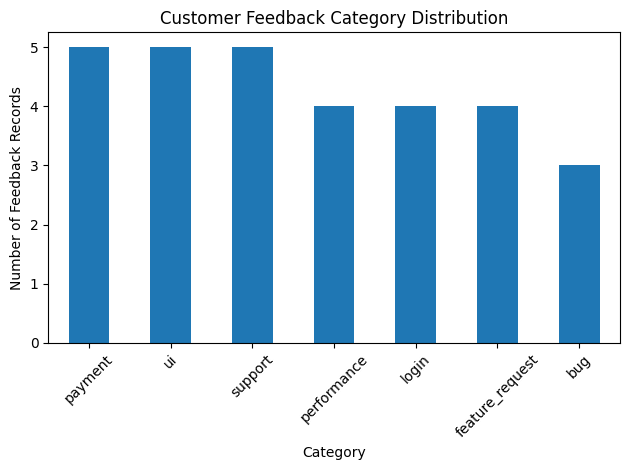

In [4]:
df["main_category"] = df["category"].apply(
    lambda x: str(x).split("|")[0]
)

category_counts = df["main_category"].value_counts()

print("Main Category Distribution:")
print(category_counts)

category_counts.plot(
    kind="bar",
    title="Customer Feedback Category Distribution"
)

plt.xlabel("Category")
plt.ylabel("Number of Feedback Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.3 Text Preprocessing

Clean the customer feedback before feature extraction.

The preprocessing steps include:

- Convert text to lowercase
- Remove URLs
- Remove numbers
- Remove punctuation
- Remove extra spaces

In [5]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_feedback"] = df["feedback"].apply(clean_text)

df[
    [
        "feedback",
        "clean_feedback",
        "main_category"
    ]
].head(10)

,feedback,clean_feedback,main_category
0,Payment is failing,payment is failing,payment
1,The application is very slow,the application is very slow,performance
2,I love the new dashboard,i love the new dashboard,ui
3,Support was very helpful,support was very helpful,support
4,Login OTP is not arriving,login otp is not arriving,login
5,The app is slow and payment fails,the app is slow and payment fails,performance
6,The application works perfectly,the application works perfectly,ui
7,Payment was successful,payment was successful,payment
8,I cannot login to my account,i cannot login to my account,login
9,Customer support did not respond,customer support did not respond,support


## 4.4 Prepare Features and Target

Use the cleaned feedback as the input feature.

The main category will be used as the target variable.

In [6]:
X = df["clean_feedback"]
y = df["main_category"]

print("Number of feedback records:", len(X))

print("\nCategory Classes:")
print(sorted(y.unique()))

Number of feedback records: 30

Category Classes:
['bug', 'feature_request', 'login', 'payment', 'performance', 'support', 'ui']


## 4.5 Train-Test Split

Split the dataset into training and testing datasets.

The test dataset contains 25% of the available feedback records.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22
Testing samples: 8


## 4.6 TF-IDF Feature Extraction

Convert customer feedback text into numerical TF-IDF features.

Unigrams and bigrams are used to capture individual words and two-word phrases.

In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (22, 95)
Testing TF-IDF shape: (8, 95)


## 4.7 Train Category Classification Model

Train a Logistic Regression model to classify customer feedback into the main complaint categories.

In [9]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Category classification model trained successfully!")

Category classification model trained successfully!


## 4.8 Predict Customer Feedback Categories

Use the trained model to predict categories for the test dataset.

In [10]:
y_pred = model.predict(X_test_tfidf)

results = pd.DataFrame({
    "Feedback": X_test.values,
    "Actual Category": y_test.values,
    "Predicted Category": y_pred
})

results.head(10)

,Feedback,Actual Category,Predicted Category
0,i cannot login to my account,login,support
1,the app loads very quickly,performance,support
2,i am happy with the service,support,support
3,payment failed twice,payment,payment
4,please add dark mode,feature_request,feature_request
5,the application works perfectly,ui,login
6,the application keeps crashing,bug,performance
7,payment processing is too slow,payment,performance


## 4.9 Model Accuracy

Calculate the accuracy of the category classification model.

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Category Classification Accuracy: {accuracy:.2%}"
)

Category Classification Accuracy: 37.50%


## 4.10 Classification Report

Generate precision, recall, and F1-score for each customer feedback category.

In [12]:
print("Category Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Category Classification Report:
                 precision    recall  f1-score   support

            bug       0.00      0.00      0.00         1
feature_request       1.00      1.00      1.00         1
          login       0.00      0.00      0.00         1
        payment       1.00      0.50      0.67         2
    performance       0.00      0.00      0.00         1
        support       0.33      1.00      0.50         1
             ui       0.00      0.00      0.00         1

       accuracy                           0.38         8
      macro avg       0.33      0.36      0.31         8
   weighted avg       0.42      0.38      0.35         8



## 4.11 Confusion Matrix

Visualize the classification performance using a confusion matrix.

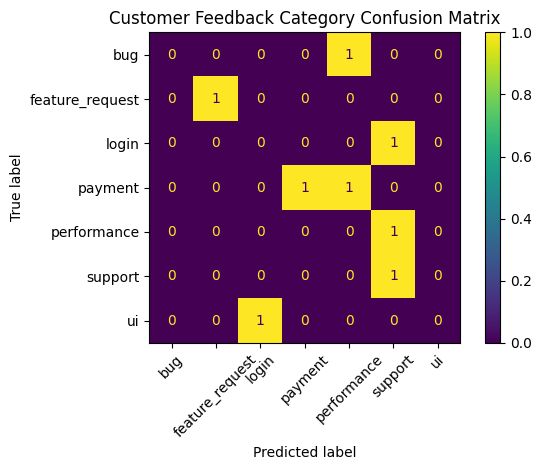

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

cm_display.plot(
    xticks_rotation=45
)

plt.title(
    "Customer Feedback Category Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 4.12 Test with New Customer Feedback

Test the category classification model with new customer feedback examples.

In [14]:
new_feedback = [
    "My payment is failing",
    "I cannot login to my account",
    "The application is very slow",
    "Please add dark mode",
    "Customer support did not respond",
    "The application keeps crashing"
]

clean_new_feedback = [
    clean_text(text)
    for text in new_feedback
]

new_feedback_tfidf = vectorizer.transform(
    clean_new_feedback
)

predicted_categories = model.predict(
    new_feedback_tfidf
)

prediction_results = pd.DataFrame({
    "Feedback": new_feedback,
    "Predicted Category": predicted_categories
})

display(prediction_results)

,Feedback,Predicted Category
0,My payment is failing,payment
1,I cannot login to my account,support
2,The application is very slow,performance
3,Please add dark mode,feature_request
4,Customer support did not respond,support
5,The application keeps crashing,performance


## 4.13 Conclusion

The customer feedback category classification system was successfully developed using NLP techniques.

The workflow includes:

1. Loading customer feedback
2. Identifying main categories
3. Text preprocessing
4. TF-IDF feature extraction
5. Logistic Regression classification
6. Category prediction
7. Model evaluation
8. Confusion matrix analysis
9. Testing with new customer feedback

The system can classify customer feedback into categories such as payment, login, performance, support, UI, bug, and feature request.